In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
# Configuración general de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

# Cargamos el dataset limpio
df = pd.read_parquet("../data/chicago_definitivo.parquet")

##  Análisis Bivariante

#### 🔹 H2 — ¿Cuáles son los barrios con más crímenes?
**Variables:** `neighborhood_name` vs número de crímenes  
**Gráfico:** Barras horizontal

Top 10 barrios con más crímenes:


,neighborhood_name,crime_count,porcentaje (%)
0,Austin,11052,6.80
1,South Shore,5565,3.43
2,Humboldt Park,5399,3.32
3,Near North Side,5228,3.22
4,North Lawndale,5151,3.17
5,Near West Side,4768,2.94
6,Auburn Gresham,4657,2.87
7,West Englewood,4574,2.82
8,Roseland,4445,2.74
9,Englewood,4336,2.67


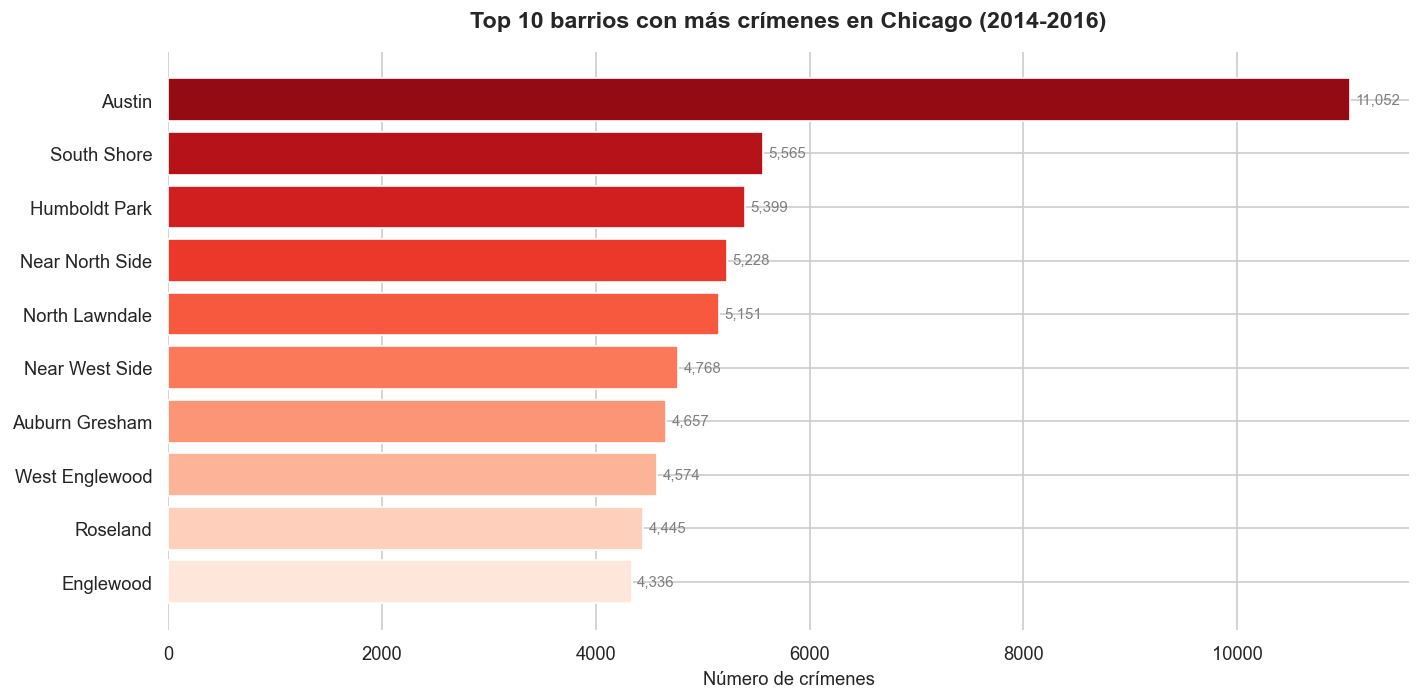


📌 CONCLUSIÓN H2:
   Barrio con más crímenes: Austin (11,052 casos, 6.80%)
   Barrio con menos crímenes: Edison Park (159 casos)
   La criminalidad NO está distribuida uniformemente entre barrios.


In [32]:
# Crímenes por barrio
crimenes_por_barrio = df.groupby("neighborhood_name").size()\
                        .sort_values(ascending=False)\
                        .reset_index(name="crime_count")
crimenes_por_barrio["porcentaje (%)"] = (crimenes_por_barrio["crime_count"] / 
                                          len(df) * 100).round(2)

# Tabla Top 10
print( "Top 10 barrios con más crímenes:")
display(crimenes_por_barrio.head(10))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
top10 = crimenes_por_barrio.head(10)
colors = sns.color_palette("Reds_r", len(top10))
bars = ax.barh(top10["neighborhood_name"], top10["crime_count"], color=colors)

for bar, val in zip(bars, top10["crime_count"]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9, color="gray")

ax.set_title("Top 10 barrios con más crímenes en Chicago (2014-2016)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Número de crímenes", fontsize=11)
ax.set_ylabel("")
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Conclusión
top1 = crimenes_por_barrio.iloc[0]
last = crimenes_por_barrio.iloc[-1]
print(f"\n📌 CONCLUSIÓN H2:")
print(f"   Barrio con más crímenes: {top1['neighborhood_name']} ({top1['crime_count']:,} casos, {top1['porcentaje (%)']:.2f}%)")
print(f"   Barrio con menos crímenes: {last['neighborhood_name']} ({last['crime_count']:,} casos)")
print(f"   La criminalidad NO está distribuida uniformemente entre barrios.")

#### 🔹 H3 — ¿Qué crímenes son los más comunes en cada barrio?
**Variables:** `Primary Type` vs `neighborhood_name`  
**Gráfico:** Heatmap

Crímenes por barrio (Top 10 x Top 10):


Primary Type,THEFT,BATTERY,NARCOTICS,CRIMINAL DAMAGE,OTHER OFFENSE,ASSAULT,DECEPTIVE PRACTICE,BURGLARY,MOTOR VEHICLE THEFT,ROBBERY
neighborhood_name,,,,,,,,,,
Austin,1406,2242,2348,851,777,700,458,348,357,435
South Shore,871,1278,485,586,479,400,251,385,168,216
Humboldt Park,633,1078,1380,442,370,322,165,150,183,202
Near North Side,2420,647,136,274,182,186,653,94,93,104
North Lawndale,563,1144,1228,466,300,333,157,184,135,216
Near West Side,1669,712,191,409,238,277,381,139,200,168
Auburn Gresham,751,1012,449,472,328,385,233,251,165,202
West Englewood,618,1006,664,478,288,366,166,222,134,168
Roseland,723,872,478,487,285,376,202,249,124,222


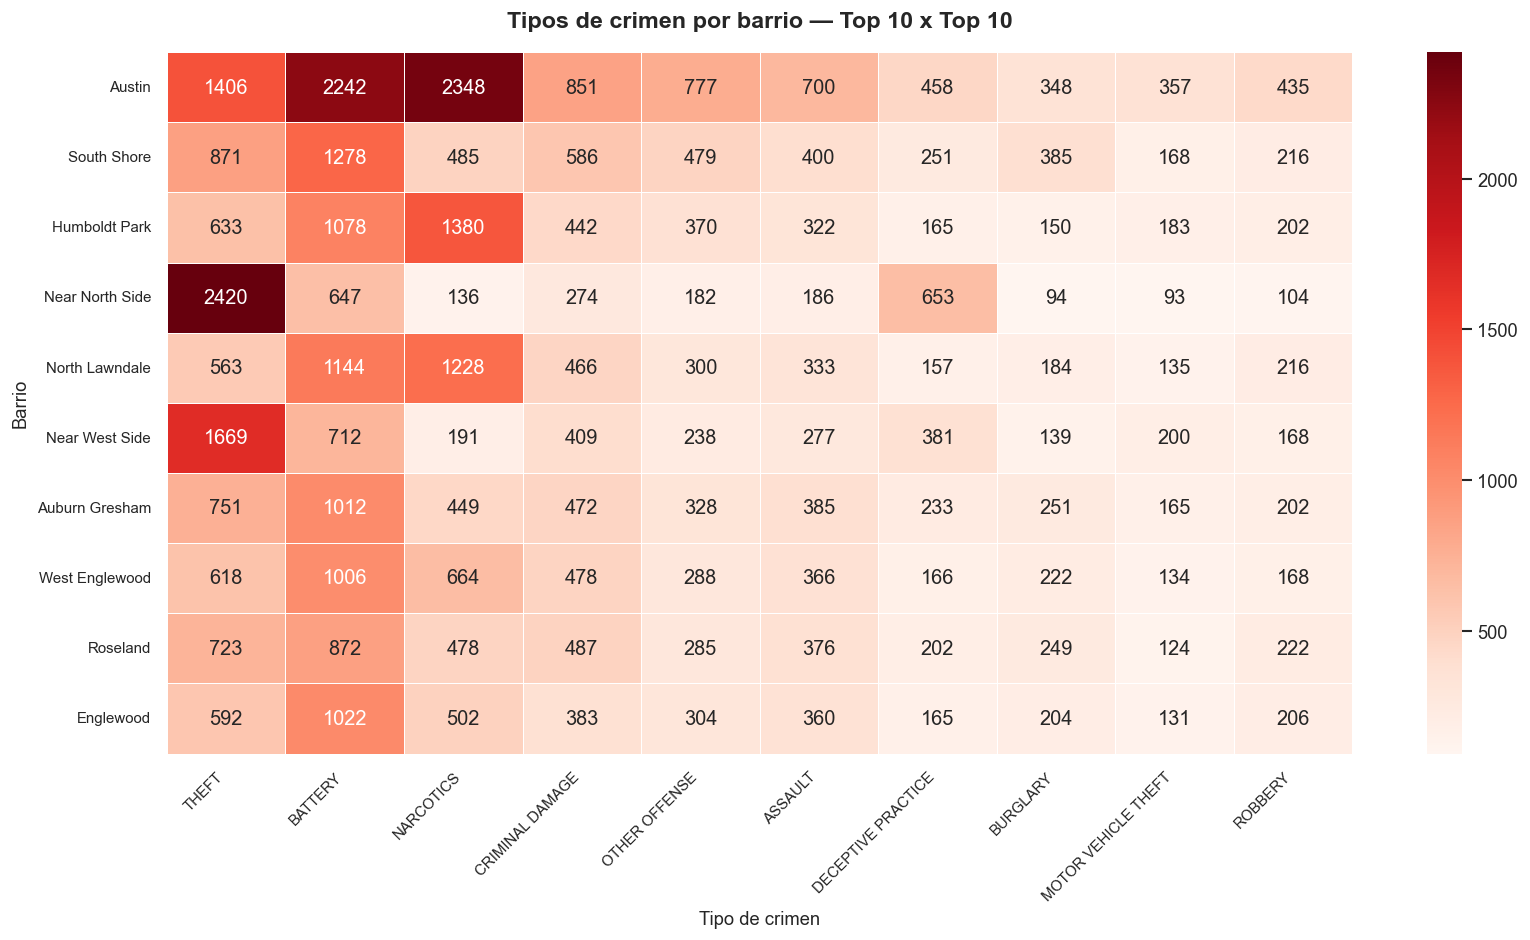


 CONCLUSIÓN H3:
   Austin: el crimen más común es NARCOTICS (2,348 casos)
   South Shore: el crimen más común es BATTERY (1,278 casos)
   Humboldt Park: el crimen más común es NARCOTICS (1,380 casos)


In [35]:
# Cruzamos barrio y tipo de crimen
h3_tabla = df.groupby(["neighborhood_name", "Primary Type"]).size()\
             .unstack(fill_value=0)

# Nos quedamos con el Top 10 barrios y Top 10 crímenes
top10_barrios = df["neighborhood_name"].value_counts().head(10).index
top10_crimes = df["Primary Type"].value_counts().head(10).index

h3_tabla = h3_tabla.loc[top10_barrios, top10_crimes]

# Tabla
print("Crímenes por barrio (Top 10 x Top 10):")
display(h3_tabla)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(h3_tabla, 
            annot=True,        # muestra los números dentro
            fmt="d",           # formato entero
            cmap="Reds",       # escala de rojos
            linewidths=0.5,    # líneas entre celdas
            ax=ax)

ax.set_title("Tipos de crimen por barrio — Top 10 x Top 10",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tipo de crimen", fontsize=11)
ax.set_ylabel("Barrio", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Conclusión
print("\n CONCLUSIÓN H3:")
for barrio in top10_barrios[:3]:
    crimen_top = h3_tabla.loc[barrio].idxmax()
    valor = h3_tabla.loc[barrio].max()
    print(f"   {barrio}: el crimen más común es {crimen_top} ({valor:,} casos)")

Hay dos patrones claros: 
- Algunos barrios tienen más NARCOTICS → relacionado con tráfico de drogas
- Otros tienen más BATTERY → relacionado con violencia física

#### 🔹 H4 — ¿Qué crímenes tienen mayor impunidad?
**Variables:** `Primary Type` vs `Arrest`  
**Gráfico:** Barras apiladas

Tasa de arresto por tipo de crimen (Top 10 con menor arresto):


,Sin arresto (%),Con arresto (%)
Primary Type,,
HUMAN TRAFFICKING,100.00,0.00
NON-CRIMINAL,100.00,0.00
NON - CRIMINAL,100.00,0.00
BURGLARY,94.48,5.52
KIDNAPPING,94.35,5.65
CRIMINAL DAMAGE,92.44,7.56
MOTOR VEHICLE THEFT,91.93,8.07
DECEPTIVE PRACTICE,90.85,9.15
ROBBERY,90.03,9.97


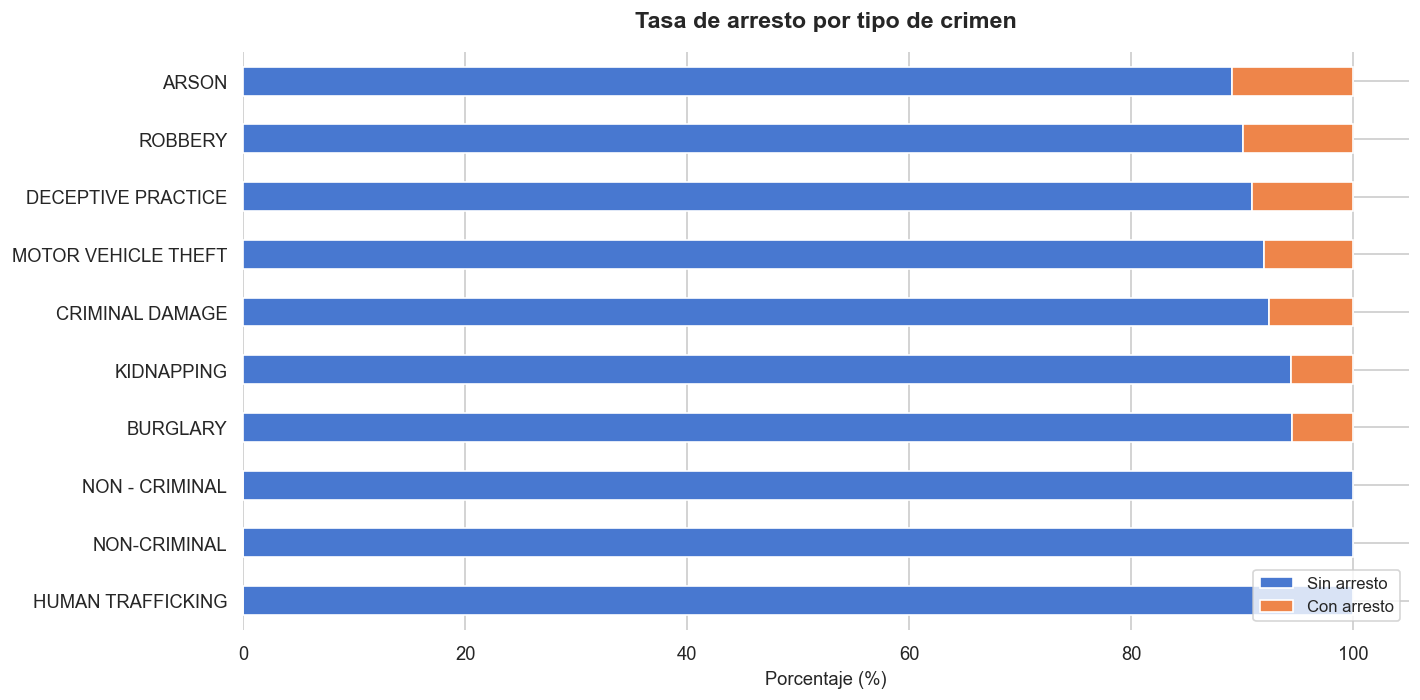


 CONCLUSIÓN H4:
   Crimen con MAYOR impunidad: HUMAN TRAFFICKING (0.0% arrestos)
   Crimen con MENOR impunidad: ARSON (10.9% arrestos)

H4 VERIFICADA: Existe una gran diferencia en la tasa dearresto según el tipo de crimen.


In [36]:
# Calculamos tasa de arresto por tipo de crimen
h4_tabla = df.groupby("Primary Type")["Arrest"].value_counts(normalize=True)\
             .unstack(fill_value=0) * 100
h4_tabla.columns = ["Sin arresto (%)", "Con arresto (%)"]
h4_tabla = h4_tabla.sort_values("Con arresto (%)").head(10).round(2)

# Tabla
print("Tasa de arresto por tipo de crimen (Top 10 con menor arresto):")
display(h4_tabla)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

h4_tabla.plot(kind="barh", stacked=True, ax=ax)

ax.set_title("Tasa de arresto por tipo de crimen",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Porcentaje (%)", fontsize=11)
ax.set_ylabel("")
ax.legend(["Sin arresto", "Con arresto"], loc="lower right", fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Conclusión
mas_impune = h4_tabla["Con arresto (%)"].idxmin()
menos_impune = h4_tabla["Con arresto (%)"].idxmax()
print(f"\n CONCLUSIÓN H4:")
print(f"   Crimen con MAYOR impunidad: {mas_impune} "
      f"({h4_tabla.loc[mas_impune, 'Con arresto (%)']:.1f}% arrestos)")
print(f"   Crimen con MENOR impunidad: {menos_impune} "
      f"({h4_tabla.loc[menos_impune, 'Con arresto (%)']:.1f}% arrestos)")
print(f"\nH4 VERIFICADA: Existe una gran diferencia en la tasa dearresto según el tipo de crimen.")

### 🔹 H5 — ¿El crimen está relacionado con el poder adquisitivo?
**Variables:** `income_category` vs número de crímenes por barrio  
**Gráfico:** Boxplot

,Categoría de renta,Media de crímenes
0,Low,2852.0
2,Upper Middle,2050.0
3,Very Low,1728.0
1,Middle,1390.0


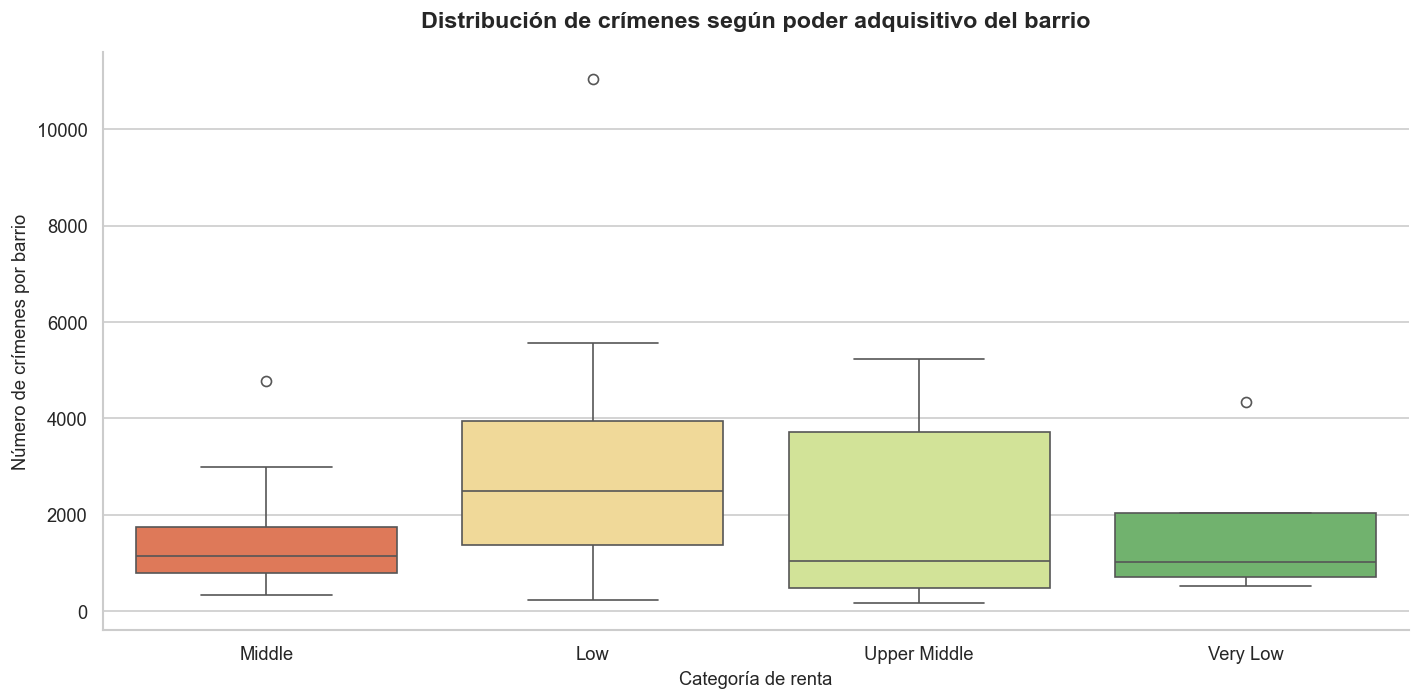


 CONCLUSIÓN H5:
   Low: media de 2852 crímenes por barrio
   Middle: media de 1390 crímenes por barrio
   Upper Middle: media de 2050 crímenes por barrio
   Very Low: media de 1728 crímenes por barrio

H5 VERIFICADA: Los barrios con menor renta concentran más crímenes.


In [37]:
# Crímenes por barrio con su categoría de renta
h5_tabla = df.groupby(["neighborhood_name", "income_category"]).size()\
             .reset_index(name="crime_count")

# Tabla resumen

tabla_h5 = h5_tabla.groupby("income_category")["crime_count"].mean().round(0)\
                   .reset_index()
tabla_h5.columns = ["Categoría de renta", "Media de crímenes"]
tabla_h5 = tabla_h5.sort_values("Media de crímenes", ascending=False)
display(tabla_h5)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=h5_tabla, x="income_category", y="crime_count",
            hue="income_category", palette="RdYlGn", legend=False, ax=ax)

ax.set_title("Distribución de crímenes según poder adquisitivo del barrio",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Categoría de renta", fontsize=11)
ax.set_ylabel("Número de crímenes por barrio", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

# Conclusión
media_por_categoria = h5_tabla.groupby("income_category")["crime_count"].mean()
print(f"\n CONCLUSIÓN H5:")
for cat, media in media_por_categoria.items():
    print(f"   {cat}: media de {media:.0f} crímenes por barrio")
print(f"\nH5 VERIFICADA: Los barrios con menor renta concentran más crímenes.")

#### 🔹 H6 — ¿La población de color está relacionada con crímenes y dificultad económica?
**Variables:** `people_of_color_category` vs número de crímenes y `hardship_index`  
**Gráfico:** Barras

Media de crímenes y hardship por categoría de población de color:


,Media de crímenes,Media hardship index
people_of_color_category,,
High,2941.0,88.59
Low,1632.0,46.32
Moderate,1273.0,77.46
Very High,2952.0,87.50
Very Low,1720.0,14.17


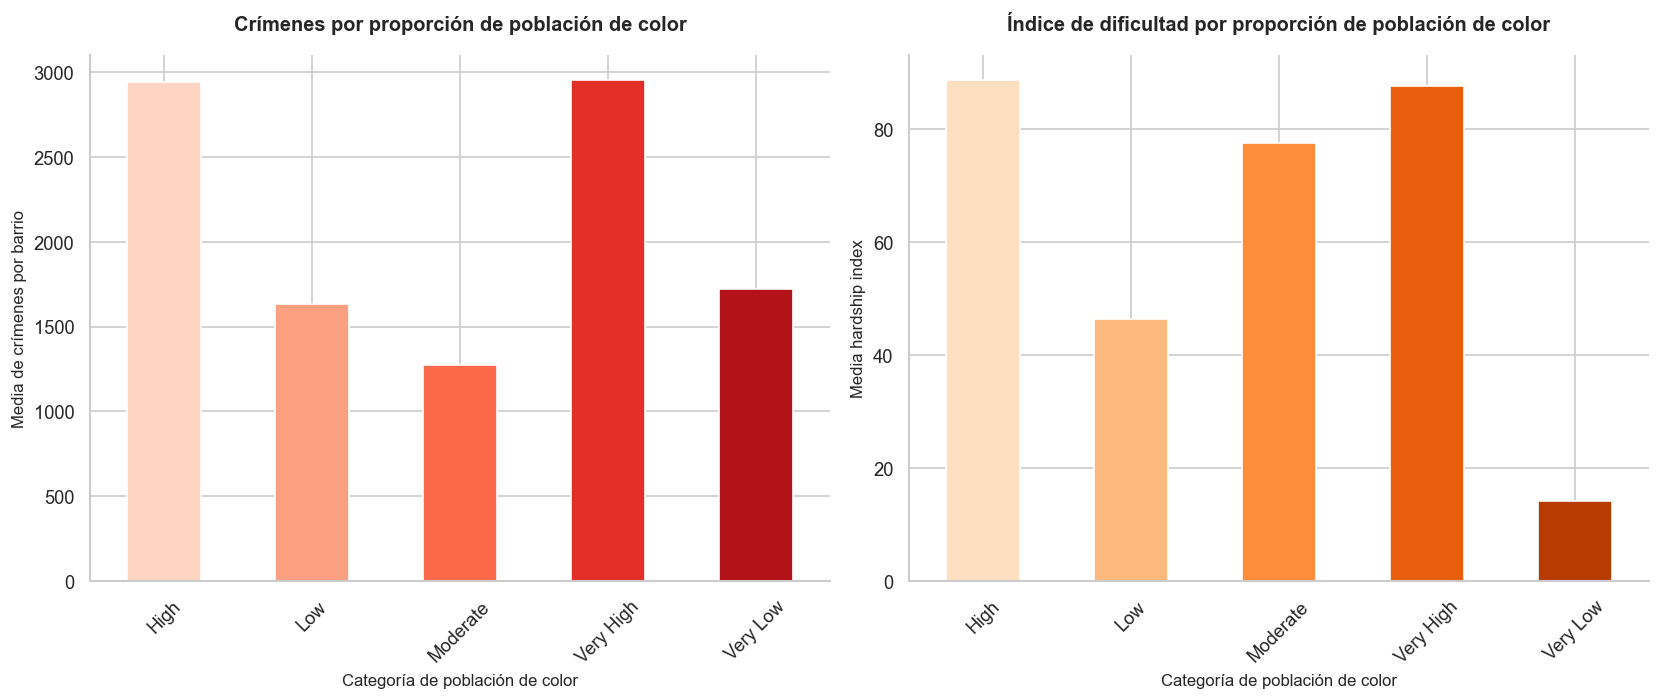


CONCLUSIÓN H6:
   Categoría con más crímenes: Very High (2.952 crímenes)
   Categoría con peor calidad de vida: High (hardship: 88.59)
   Los barrios con mayor proporción de población de color tienen más crímenes y peor calidad de vida.
   Esto sugiere una relación entre discriminación estructural, dificultad económica y criminalidad


In [38]:
# Crímenes por categoría de población de color
h6_crimenes = df.groupby(["neighborhood_name", "people_of_color_category"]).size()\
                .reset_index(name="crime_count")
h6_media_crimenes = h6_crimenes.groupby("people_of_color_category")["crime_count"].mean().round(0)

# Hardship por categoría de población de color
h6_hardship = df.groupby("people_of_color_category")["hardship_index"].mean().round(2)

# Tabla resumen
print("Media de crímenes y hardship por categoría de población de color:")
tabla_h6 = pd.DataFrame({
    "Media de crímenes": h6_media_crimenes,
    "Media hardship index": h6_hardship
})
display(tabla_h6)

# Gráfico — dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1 — crímenes
h6_media_crimenes.plot(kind="bar", ax=ax1, color=sns.color_palette("Reds", len(h6_media_crimenes)))
ax1.set_title("Crímenes por proporción de población de color",
              fontsize=12, fontweight="bold", pad=15)
ax1.set_xlabel("Categoría de población de color", fontsize=10)
ax1.set_ylabel("Media de crímenes por barrio", fontsize=10)
ax1.tick_params(axis="x", rotation=45)
sns.despine(ax=ax1)

# Gráfico 2 — hardship
h6_hardship.plot(kind="bar", ax=ax2, color=sns.color_palette("Oranges", len(h6_hardship)))
ax2.set_title("Índice de dificultad por proporción de población de color",
              fontsize=12, fontweight="bold", pad=15)
ax2.set_xlabel("Categoría de población de color", fontsize=10)
ax2.set_ylabel("Media hardship index", fontsize=10)
ax2.tick_params(axis="x", rotation=45)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

# Conclusión
print(f"\nCONCLUSIÓN H6:")
print(f"   Categoría con más crímenes: Very High (2.952 crímenes)")
print(f"   Categoría con peor calidad de vida: High (hardship: 88.59)")
print(f"   Los barrios con mayor proporción de población de color tienen más crímenes y peor calidad de vida.")
print(f"   Esto sugiere una relación entre discriminación estructural, dificultad económica y criminalidad")


#### 🔹 H7 — ¿Las áreas con menos oportunidades educativas tienen mayor criminalidad?
**Variables:** `child_opportunity_category` vs número de crímenes por barrio  
**Gráfico:** Barras

Media de crímenes por oportunidad educativa:


,Oportunidad educativa,Media de crímenes
4,Very Low,2971.0
0,High,2315.0
3,Very High,2119.0
1,Low,1442.0
2,Moderate,1269.0


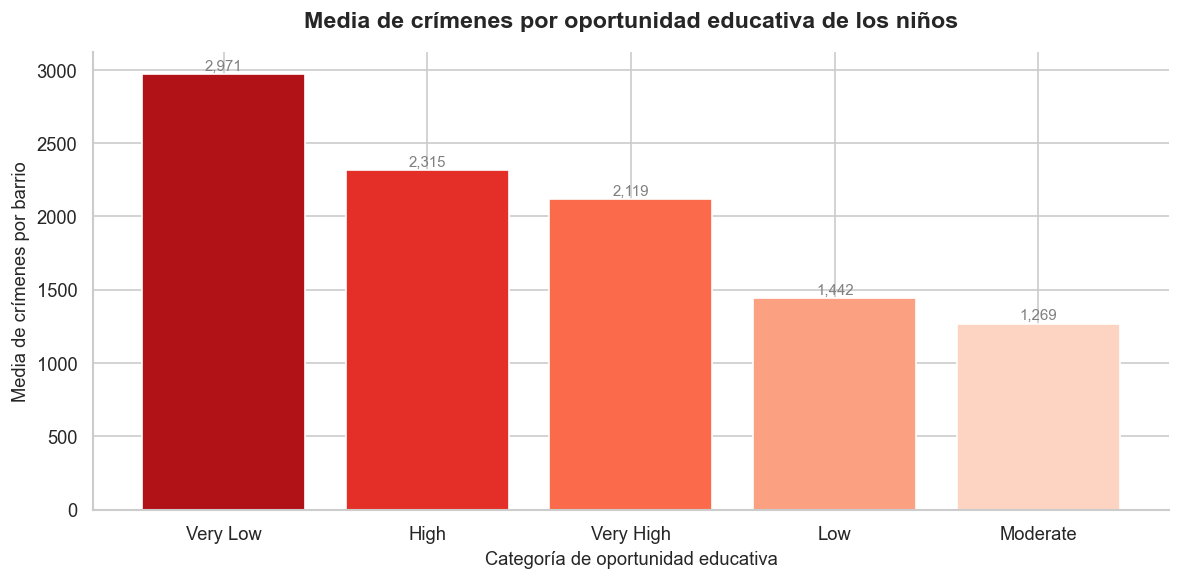


 CONCLUSIÓN H7:
   Mayor criminalidad: Very Low (2,971 crímenes)
   Menor criminalidad: Moderate (1,269 crímenes)

 Los barrios con menos oportunidades educativas tienen mayor concentración de crímenes.


In [39]:
# Crímenes por categoría de oportunidad educativa
h7_tabla = df.groupby(["neighborhood_name", "child_opportunity_category"]).size()\
             .reset_index(name="crime_count")
h7_media = h7_tabla.groupby("child_opportunity_category")["crime_count"]\
                   .mean().round(0).reset_index()
h7_media.columns = ["Oportunidad educativa", "Media de crímenes"]
h7_media = h7_media.sort_values("Media de crímenes", ascending=False)

# Tabla
from IPython.display import display
print("Media de crímenes por oportunidad educativa:")
display(h7_media)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(h7_media["Oportunidad educativa"], 
              h7_media["Media de crímenes"],
              color=sns.color_palette("Reds_r", len(h7_media)))

for bar, val in zip(bars, h7_media["Media de crímenes"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,.0f}", ha="center", fontsize=9, color="gray")

ax.set_title("Media de crímenes por oportunidad educativa de los niños",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Categoría de oportunidad educativa", fontsize=11)
ax.set_ylabel("Media de crímenes por barrio", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

# Conclusión
top1 = h7_media.iloc[0]
last = h7_media.iloc[-1]
print(f"\n CONCLUSIÓN H7:")
print(f"   Mayor criminalidad: {top1['Oportunidad educativa']} ({top1['Media de crímenes']:,.0f} crímenes)")
print(f"   Menor criminalidad: {last['Oportunidad educativa']} ({last['Media de crímenes']:,.0f} crímenes)")
print(f"\n Los barrios con menos oportunidades educativas tienen mayor concentración de crímenes.")

#### 🔹 H8 — ¿El índice de calidad de vida está relacionado con el poder adquisitivo?
**Variables:** `hardship_index` vs `median_income`  
**Gráfico:** Scatter plot

Hardship Index vs Renta media por barrio:


,Barrio,Hardship Index,Renta media
59,Riverdale,99.47,19083.87
23,Englewood,97.17,28328.79
71,West Garfield Park,95.63,31313.03
64,South Lawndale,95.55,46463.41
70,West Englewood,95.19,37096.11
68,Washington Park,94.54,31372.10
26,Gage Park,94.04,51437.82
52,North Lawndale,94.02,33843.81
25,Fuller Park,93.86,28455.65
50,New City,93.75,51462.05


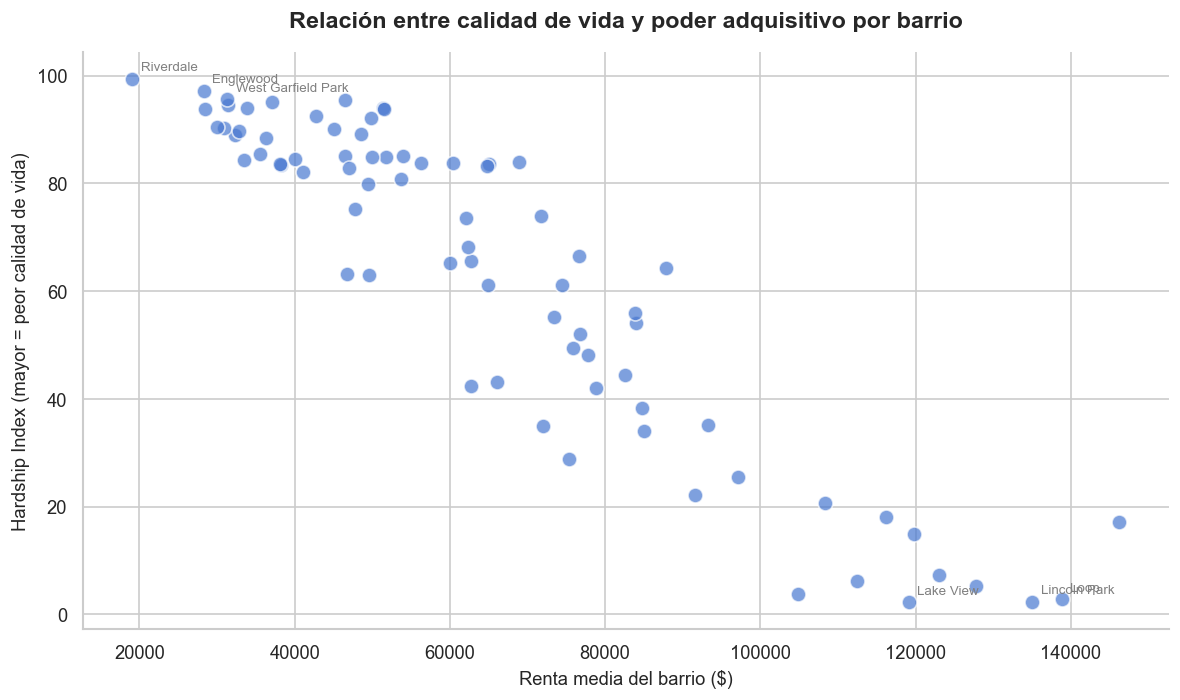


CONCLUSIÓN H8:
   Correlación entre hardship index y renta media: -0.92
   Barrio con mayor renta: Forest Glen ($146,274)
   Barrio con menor renta: Riverdale ($19,084)
   A mayor renta media, menor índice de dificultad económica.
   Calidad de vida y poder adquisitivo están estrechamente relacionados.


In [43]:
# Tabla por barrio con hardship y renta
h8_tabla = df.groupby("neighborhood_name").agg(
    hardship_index=("hardship_index", "mean"),
    median_income=("median_income", "mean")
).round(2).reset_index()
h8_tabla.columns = ["Barrio", "Hardship Index", "Renta media"]

# Tabla
print("Hardship Index vs Renta media por barrio:")
display(h8_tabla.sort_values("Hardship Index", ascending=False).head(10))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(h8_tabla["Renta media"], h8_tabla["Hardship Index"],
            alpha=0.7, edgecolors="white", s=80)

# Etiquetas de los barrios más extremos
for _, row in h8_tabla.nlargest(3, "Hardship Index").iterrows():
    ax.annotate(row["Barrio"], 
                (row["Renta media"], row["Hardship Index"]),
                fontsize=8, color="gray",
                xytext=(5, 5), textcoords="offset points")

for _, row in h8_tabla.nsmallest(3, "Hardship Index").iterrows():
    ax.annotate(row["Barrio"],
                (row["Renta media"], row["Hardship Index"]),
                fontsize=8, color="gray",
                xytext=(5, 5), textcoords="offset points")

ax.set_title("Relación entre calidad de vida y poder adquisitivo por barrio",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Renta media del barrio ($)", fontsize=11)
ax.set_ylabel("Hardship Index (mayor = peor calidad de vida)", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

# Correlación
correlacion = h8_tabla["Hardship Index"].corr(h8_tabla["Renta media"])

# Barrio con mayor y menor renta
barrio_mayor_renta = h8_tabla.loc[h8_tabla["Renta media"].idxmax(), "Barrio"]
valor_mayor_renta = h8_tabla["Renta media"].max()

barrio_menor_renta = h8_tabla.loc[h8_tabla["Renta media"].idxmin(), "Barrio"]
valor_menor_renta = h8_tabla["Renta media"].min()

print(f"\nCONCLUSIÓN H8:")
print(f"   Correlación entre hardship index y renta media: {correlacion:.2f}")
print(f"   Barrio con mayor renta: {barrio_mayor_renta} (${valor_mayor_renta:,.0f})")
print(f"   Barrio con menor renta: {barrio_menor_renta} (${valor_menor_renta:,.0f})")
print(f"   A mayor renta media, menor índice de dificultad económica.")
print(f"   Calidad de vida y poder adquisitivo están estrechamente relacionados.")


#### 🔹 H9 — ¿Los delitos domésticos tienen el mismo % de arrestos en zonas con menor calidad de vida?
**Variables:** `Domestic` + `Arrest` vs `hardship_category`  
**Gráfico:** Barras agrupadas

Tasa de arresto en crímenes domésticos por calidad de vida:


,Calidad de vida,Sin arresto (%),Con arresto (%)
0,High,78.11,21.89
1,Low,78.31,21.69
2,Moderate,79.64,20.36
3,Very High,80.37,19.63
4,Very Low,78.33,21.67


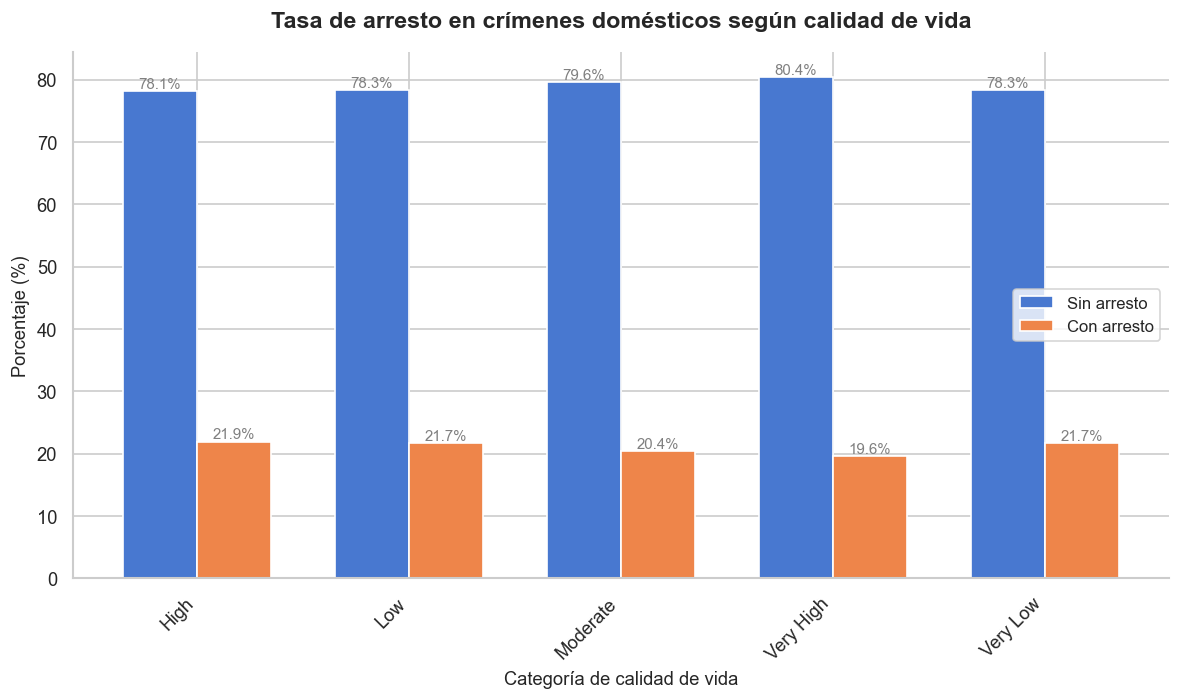


CONCLUSIÓN H9:
   Mayor tasa de arresto en domésticos: High (21.9%)
   Menor tasa de arresto en domésticos: Very High (19.6%)
   Los delitos domésticos NO tienen la misma tasa de arresto según la calidad de vida del barrio
   El porcentaje de arresto es muy parecido entre categorías, con un alto porcentaje a no arresto.


In [46]:
# Filtramos solo crímenes domésticos
domesticos = df[df["Domestic"] == True]

# Tasa de arresto en crímenes domésticos por categoría de hardship
h9_tabla = domesticos.groupby("hardship_category")["Arrest"]\
                     .value_counts(normalize=True).unstack(fill_value=0) * 100
h9_tabla.columns = ["Sin arresto (%)", "Con arresto (%)"]
h9_tabla = h9_tabla.round(2).reset_index()
h9_tabla.columns = ["Calidad de vida", "Sin arresto (%)", "Con arresto (%)"]

# Tabla
print("Tasa de arresto en crímenes domésticos por calidad de vida:")
display(h9_tabla)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(h9_tabla))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], h9_tabla["Sin arresto (%)"],
               width, label="Sin arresto")
bars2 = ax.bar([i + width/2 for i in x], h9_tabla["Con arresto (%)"],
               width, label="Con arresto")

# Etiquetas encima de cada barra
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", fontsize=9, color="gray")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", fontsize=9, color="gray")

ax.set_title("Tasa de arresto en crímenes domésticos según calidad de vida",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Categoría de calidad de vida", fontsize=11)
ax.set_ylabel("Porcentaje (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(h9_tabla["Calidad de vida"], rotation=45, ha="right")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

# Conclusión
max_arresto = h9_tabla.loc[h9_tabla["Con arresto (%)"].idxmax(), "Calidad de vida"]
min_arresto = h9_tabla.loc[h9_tabla["Con arresto (%)"].idxmin(), "Calidad de vida"]
print(f"\nCONCLUSIÓN H9:")
print(f"   Mayor tasa de arresto en domésticos: {max_arresto} "
      f"({h9_tabla['Con arresto (%)'].max():.1f}%)")
print(f"   Menor tasa de arresto en domésticos: {min_arresto} "
      f"({h9_tabla['Con arresto (%)'].min():.1f}%)")
print(f"   Los delitos domésticos NO tienen la misma tasa de arresto según la calidad de vida del barrio" )
print(f"   El porcentaje de arresto es muy parecido entre categorías, con un alto porcentaje a no arresto.")
